### Experiment 1: Single Recommender -- No Switching Mechanism
- Create a controlled group of consumers (children movies fans) 10% of the consumers population
- Create a group of providers (children movies producers) 10% of the providers population
- Subscribe all the users to one general recommender 

In [4]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod

In [5]:
random_seed, np_random_seed = random.seed(505), np.random.seed(505)

In [6]:
pd.options.mode.chained_assignment = None  # default='warn'

In [7]:
from modules.classes import Document, Provider, Consumer, Recommender
from modules.samplers import provider_sampler, consumer_sampler
from modules.genre_preferences import generate_genre_preferences
from modules.recommenders import PopularRecommender

In [8]:
# Movie Lens
ratings_df = pd.read_csv('ml-latest-small/merge_movie_ratings.csv')
movies_df = pd.read_csv('ml-latest-small/complete_movies_metadata.csv', low_memory=False)
movies_with_ratings_df = ratings_df.merge(movies_df, on='movieId', how='left')
documents_df = movies_with_ratings_df[['movieId','rating','genres']].groupby(['movieId','genres']).mean().reset_index()

In [9]:
# scaling the rating to 0 - 1
documents_df['rating'] = documents_df['rating'].apply(lambda x: x / 5)

(array([ 105.,  180.,  299.,  680.,  951., 1808., 2164., 2207.,  771.,
         319.]),
 array([0.1 , 0.19, 0.28, 0.37, 0.46, 0.55, 0.64, 0.73, 0.82, 0.91, 1.  ]),
 <BarContainer object of 10 artists>)

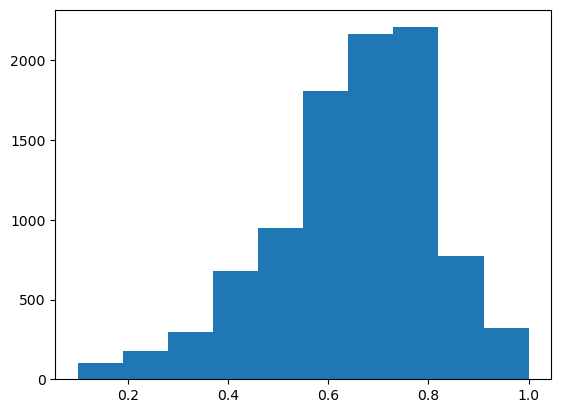

In [10]:
plt.hist(documents_df['rating'])

In [11]:
# Checking the dictionaries distribution
#import matplotlib.pyplot as plt

#genre_dict = dict()
#for genre in movies_df['genres']:
#    genres = genre.split('|')
#    for curr_genre in genres:
#        if curr_genre in genre_dict.keys():
#            genre_dict[curr_genre] += 1
#        else:
#            genre_dict[curr_genre] = 1
            
#plt.bar(range(len(genre_dict)), list(genre_dict.values()), align='center')
#plt.xticks(range(len(genre_dict)), list(genre_dict.keys()))
#plt.xticks(rotation=90)
#plt.show()

In [12]:
movies_df.head()

,id,title,original_language,genres,release_date,overview,budget,revenue,runtime,vote_average,vote_count,imdb_id,movieId,imdbId,tmdbId,production_companies,production_countries,spoken_languages,popularity
0,000862,Toy Story,en,Animation|Comedy|Family,1995-10-30,"Led by Woody, Andy's toys live happily in his ...",30000000.0,373554033.0,81.0,7.7,5415.0,tt0114709,1.0,114709.0,862.0,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}]",21.946943
1,008844,Jumanji,en,Adventure|Fantasy|Family,1995-12-15,When siblings Judy and Peter discover an encha...,65000000.0,262797249.0,104.0,6.9,2413.0,tt0113497,2.0,113497.0,8844.0,"[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",17.015539
2,015602,Grumpier Old Men,en,Romance|Comedy,1995-12-22,A family wedding reignites the ancient feud be...,0.0,0.0,101.0,6.5,92.0,tt0113228,3.0,113228.0,15602.0,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}]",11.7129
3,031357,Waiting to Exhale,en,Comedy|Drama|Romance,1995-12-22,"Cheated on, mistreated and stepped on, the wom...",16000000.0,81452156.0,127.0,6.1,34.0,tt0114885,4.0,114885.0,31357.0,[{'name': 'Twentieth Century Fox Film Corporat...,"[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}]",3.859495
4,011862,Father of the Bride Part II,en,Comedy,1995-02-10,Just when George Banks has recovered from his ...,0.0,76578911.0,106.0,5.7,173.0,tt0113041,5.0,113041.0,11862.0,"[{'name': 'Sandollar Productions', 'id': 5842}...","[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}]",8.387519


In [13]:
# User Genre preferences using bayesian average
user_genre_preference = generate_genre_preferences(movies_with_ratings_df)

In [14]:
user_genre_preference

,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,Foreign,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
userId,,,,,,,,,,,,,,,,,,,,
1,0.058652,0.059100,0.060704,0.058682,0.059250,0.000000,0.059181,0.059507,0.058494,0.000000,0.059398,0.055325,0.059769,0.058020,0.058069,0.058393,0.000000,0.058112,0.059746,0.059599
2,0.086378,0.084142,0.000000,0.085335,0.081638,0.086527,0.082751,0.000000,0.000000,0.000000,0.000000,0.076988,0.000000,0.080565,0.000000,0.083248,0.000000,0.084142,0.087720,0.080565
3,0.075255,0.067155,0.041570,0.055181,0.041570,0.000000,0.041570,0.041570,0.064861,0.083917,0.041570,0.086186,0.041570,0.062743,0.053480,0.079846,0.000000,0.080388,0.041570,0.000000
4,0.052093,0.053280,0.054785,0.052108,0.053173,0.054785,0.052044,0.052721,0.051798,0.047906,0.050772,0.053495,0.054140,0.052463,0.052065,0.050271,0.000000,0.053679,0.054785,0.053638
5,0.055484,0.055975,0.062224,0.058088,0.059161,0.000000,0.058477,0.060999,0.060386,0.000000,0.060386,0.054872,0.065900,0.058548,0.056841,0.052115,0.000000,0.057935,0.056710,0.065900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,0.047926,0.048767,0.050559,0.049881,0.049977,0.050013,0.050950,0.049443,0.049851,0.051208,0.051294,0.048800,0.050706,0.050476,0.050566,0.049535,0.049535,0.049491,0.051010,0.050013
607,0.058344,0.057860,0.056192,0.055973,0.060498,0.000000,0.060050,0.056374,0.058804,0.000000,0.062933,0.060742,0.055560,0.062815,0.056150,0.056344,0.000000,0.060067,0.061311,0.059984
608,0.056769,0.055340,0.055198,0.052637,0.058061,0.054443,0.056751,0.050971,0.054253,0.000000,0.059600,0.056308,0.052788,0.057251,0.054040,0.055841,0.000000,0.057671,0.058345,0.053734


In [15]:
sampled_users = user_genre_preference.sample(600)
# Shuffle the sampled users to randomize the order
sampled_users = sampled_users.sample(frac=1).reset_index(drop=True)

In [16]:
### Users that are interested in niche movies
ten_percent = int(len(sampled_users) * 0.1)
users_niche_movies = sampled_users[:ten_percent]
users_general_interest = sampled_users[ten_percent:]

In [17]:
# Selecting the Niche Genre
niche_genre = 'Western'

other_genres = list(users_niche_movies.columns)
other_genres.remove(niche_genre)

### update the genre preferences for niche movies fans
users_niche_movies[niche_genre] = np.where(users_niche_movies[niche_genre] > 0, users_niche_movies[niche_genre] * 4, 0.2) 
users_niche_movies[other_genres] /= 4

### update the genre preferences for the general movie fans
users_general_interest[niche_genre] /= 4

In [18]:
users_niche_movies.columns

Index(['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary',
       'Drama', 'Family', 'Fantasy', 'Foreign', 'History', 'Horror', 'Music',
       'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War',
       'Western'],
      dtype='object')

#### Experiment: Running One Recommender System

In [20]:
niche_consumers_list = consumer_sampler(category_preferences_df=users_niche_movies, favorite_categories=set([niche_genre]))
general_consumers_list = consumer_sampler(category_preferences_df=users_general_interest)
consumers_list = niche_consumers_list + general_consumers_list
random.shuffle(consumers_list)

In [21]:
len(consumers_list)

600

In [22]:
niche_consumers_set = set([consumer.consumer_id for consumer in niche_consumers_list])
general_consumers_set = set([consumer.consumer_id for consumer in general_consumers_list])

In [23]:
# specialized providers
niche_documents = documents_df[documents_df['genres'].str.contains(niche_genre)]

#### Competing recommender systems -- swithcing mechanism

In [25]:
def run_competing_rec_experiment_df_export(consumers, providers, recommenders, num_days=5, slate_size=3, num_cycles=1):
    """
    Run a multi-recommender experiment.

    Args:
        consumers (list): List of Consumer instances.
        providers (list): List of Provider instances.
        recommenders (dict): Dictionary of Recommender instances where keys are recommender IDs.
        num_days (int, optional): Number of days to run the experiment (default is 5).
        slate_size (int, optional): Number of documents to recommend to each consumer (default is 3).
        
    Returns:
        pd.DataFrame: DataFrame containing provider data.
        pd.DataFrame: DataFrame containing consumer data.
        pd.DataFrame: DataFrame containing recommender system data.
    """
    provider_data = []
    consumer_data = []
    recommender_data = []
    customers_recommender_choice = []
    
    recommender_values = list(recommenders.values())
    general_recommender = recommender_values[0]
    
    # Subscribe consumers to the recommender
    for consumer in consumers:
        general_recommender.connect_consumer(consumer)
        consumer.subscribe_to_recommender_system(general_recommender.recommender_id)
        
    print('General Recommender', general_recommender.connected_consumers.keys())
    
    # Subscribe providers to both recommenders
    for provider in providers:   
        general_recommender.connect_provider(provider)
        provider.subscribe_to_recommender_system(general_recommender.recommender_id)
        
    
    ### LOGGING ###
    print('Connected to General recommender:', len(general_recommender.connected_consumers))
    
    # Run the experiment for the specified number of days
    for cycle in range(1, num_cycles + 1):
        for day in range(1, num_days + 1):
            print("===============> Day:", day, "<===============")
            # Organize consumers into lists based on the recommender they chose
            consumers_by_recommender = {recommender_id: [] for recommender_id in recommenders.keys()}
            for consumer in consumers:  # Iterate over the consumers for the current recommender ID
                chosen_recommender_id = consumer.choose_recommender()
                if chosen_recommender_id is None:
                    continue
                # Append recommender to consumer to evaluate UCB
                customers_recommender_choice.append([consumer.consumer_id, chosen_recommender_id]) # used for analysis
                consumers_by_recommender[chosen_recommender_id].append(consumer)
            
            # Make recommendations for each recommender's associated consumers
            recommendations = {}
            for recommender_id, recommender_consumers in consumers_by_recommender.items():
                recommender = recommenders[recommender_id]
                slate_documents = recommender.recommend_documents(recommender_consumers, slate_size=slate_size)
                for consumer in recommender_consumers:
                    recommendations[consumer.consumer_id] = (recommender_id, slate_documents[consumer.consumer_id])

            # Simulate user response, update satisfaction scores, and record clicks
            clicked_documents = {consumer.consumer_id: [] for consumer in consumers}  # Initialize with empty lists
            for consumer in consumers:
                # continue if the consumer is not connected to any recommenders
                if len(consumer.available_recommenders) == 0:
                    print('Consumer is not connected to any recommenders')
                    continue
                    
                consumer_id = consumer.consumer_id
                recommender_id, recommended_documents = recommendations[consumer_id]
                slate_documents = recommended_documents
                chosen_recommender_id = recommender_id  # Choose recommender for the current user
                responses = consumer.simulate_response(slate_documents, recommender_system_id=chosen_recommender_id)
                
                # Collect clicked items
                for i, response in enumerate(responses):
                    if response.get('click', 0) == 1:
                        clicked_documents[consumer_id].append(slate_documents[i])
                        recommenders[chosen_recommender_id].record_click(consumer_id, slate_documents[i])
                        
#         # Switching at the end of each cycle
#         for consumer in consumers:
#             # Get the connected recommender
#             for key, value in consumer.connected_recommenders.copy().items():
#                 if value == 0:  # if not connected; break
#                     continue
#                 recommender_id = key
                
#                 if consumer.satisfaction_scores[recommender_id] <= 0.03: # threshold
#                     # disconnect from the recommender
#                     # if currently connected to sci-fi recommender switch to horror
#                     if consumer.consumer_id in recommenders[recommender_id].connected_consumers.keys():
#                         print(f'Disconnect consumer {consumer.consumer_id} from recommender {recommender_id} ')
#                         # disconnect from recommender
#                         recommenders[recommender_id].disconnect_consumer(consumer)
#                         consumer.unsubscribe_from_recommender_system(recommenders[recommender_id])
#                         print(consumer.connected_recommenders)

        # ### LOGGING ###
        # print('Connected to sci-fi recommender:', len(scifi_recommender.connected_consumers))
        # print('Connected to horror recommender:', len(horror_recommender.connected_consumers))  
            
        # Charge subscription fees to providers
        for recommender in recommenders.values():
            recommender.charge_subscription_fees()
            
        # Get profit for each provider
        for provider in providers:
            for recommender_id, recommender in recommenders.items():
                if recommender_id in provider.connected_recommenders.keys():
                    provider_data.append([
                        provider.provider_id,
                        recommender_id,
                        provider.profit.get(recommender_id, [0])[cycle-1] if cycle <= len(provider.profit.get(recommender_id, [0])) else 0,
                        cycle,
                        provider.pay_cycle_fee.get(recommender_id, [0])[cycle-1] if cycle <= len(provider.pay_cycle_fee.get(recommender_id, [0])) else 0,
                        provider.pay_cycle_clicks.get(recommender_id, [0])[cycle-1] if cycle <= len(provider.pay_cycle_clicks.get(recommender_id, [0])) else 0,
                        provider.pay_cycle_shows.get(recommender_id, [0])[cycle-1] if cycle <= len(provider.pay_cycle_shows.get(recommender_id, [0])) else 0,
                        len([rec for rec in provider.connected_recommenders.keys() if provider.connected_recommenders[rec] == 1]),
                        'niche' if provider.provider_id in niche_providers_set else 'general'
                    ])
        for consumer in consumers:
            for recommender_id, recommender in recommenders.items():
                if recommender_id in consumer.connected_recommenders.keys():
                    consumer_id = consumer.consumer_id
                    consumer_satisfaction_score = consumer.get_satisfaction_score(recommender_system_id=recommender_id)
                    rec_state = 'connected' if consumer.connected_recommenders[recommender_id] == 1 else ''
                    controlled = 'niche' if consumer.consumer_id in niche_consumers_set else 'general'
                    consumer_data.append([consumer_id, recommender_id, cycle, consumer_satisfaction_score, rec_state, controlled])
        
        # Update the subscription for each provider
        for provider in providers:
            unsubscribed_list = provider.update_recommender_subscription()
            for recommender_id, recommender in recommenders.items():
                if recommender_id in unsubscribed_list:
                    recommender.disconnect_provider(provider.provider_id)
                    
        for recommender_id, recommender in recommenders.items():
            num_connected_providers = len(recommender.connected_providers)
            num_connected_consumers = len(recommender.connected_consumers)
            total_profit = recommender.profit[-1]
            recommender_data.append([recommender_id, num_connected_providers, num_connected_consumers, total_profit, cycle])
        
        print("\n====================================================")    
        print("===============> Finished Cycle:", cycle, "<================")
        print("==================================================== \n")   
            
    # Convert lists to DataFrames
    provider_df = pd.DataFrame(provider_data, columns=['provider_id', 'recommender_id', 'profit', 'cycle', 'fee', 'clicks', 'shows','connected_recommenders','controlled'])
    consumer_df = pd.DataFrame(consumer_data, columns=['consumer_id', 'recommender_id', 'cycle', 'satisfaction_score','rec_state','controlled'])
    recommender_df = pd.DataFrame(recommender_data, columns=['recommender_id', 'num_connected_providers', 'num_connected_consumers', 'total_profit','cycle'])
    customer_recommender_df = pd.DataFrame(customers_recommender_choice, columns=['customer_id', 'recommender_id'])

    return provider_df, consumer_df, recommender_df, customer_recommender_df

In [26]:
import pandas as pd
import numpy as np
from collections import Counter

# Define the sets of variables for different experiments
experiments = [
    {
        "name": "Experiment 1",
        "num_days": 30,
        "num_cycles": 60,
        "slate_size": 5,
        "exploration_prob": 0.3,
        "num_recommenders": 1,
        "specialized_categories":[
            set(), 
        ],
        "prohibited_categories":[
            set(), 
        ],
        "weighted_category":[ # value between 0 and 1. default=0.5
            {}, 
        ],
    },
]

# List of random seeds
random_seeds = [random_seed]

# Initialize DataFrame to store category frequencies per experiment and recommender
category_freq_df = pd.DataFrame(columns=['experiment_name', 'recommender_id', 'category', 'frequency'])

# Initialize lists to store results of all experiments
all_provider_data = []
all_consumer_data = []
all_recommender_data = []
all_customer_recommender_data = []

# Consumers
num_consumers = consumers_list

# Providers
doc_mean_std = (500,100) 
num_docs = 100 
num_providers = 10

# Recommender system base fee
recs_fee = 0
decremental_fee_flag = False # base_fee = recs_fee / number of recs

for seed in random_seeds:
    np.random.seed(seed)
    random.seed(seed)
    # Loop over each experiment configuration
    for i, exp in enumerate(experiments):
        # Initialize providers
        niche_providers_list = provider_sampler(niche_documents, int(num_providers * 0.1), num_docs, starting_id=1) # 10% are niche providers
        niche_providers_set = set([provider.provider_id for provider in niche_providers_list])
        
        general_providers_list = provider_sampler(documents_df, int(num_providers * 0.9), num_docs, starting_id=2) # 90% are general providers
        
        providers_list = niche_providers_list + general_providers_list
        random.shuffle(providers_list)

        print(f"Running experiment: {exp['name']} | seed: {seed} | number of recommenders: {exp['num_recommenders']}")
        
        # Initialize recommenders for this experiment
        recommenders = {}
        for j in range(exp['num_recommenders']):
            recommender_id = f"popular_{j+1}_exp_{i}_seed_{seed}"
            
            # decrease the fee based on the number of recommenders
            if decremental_fee_flag == True:
                base_fee = recs_fee / exp['num_recommenders']
            else:
                base_fee = recs_fee
            
            recommenders[recommender_id] = PopularRecommender(
                recommender_id=recommender_id,
                fee_per_click=0.1,
                fee_per_show=0.01,
                base_fee=base_fee,
                exploration_prob=exp['exploration_prob'],
                prohibited_categories=exp['prohibited_categories'][j], # gets the prohibited categories from "prohibited_categories":[[],[]]
                weighted_category=exp['weighted_category'][j],
                specialized_categories=exp['specialized_categories'][j]
            )

        # Run the experiment
        provider_df, consumer_df, recommender_df, customer_recommender_df = run_competing_rec_experiment_df_export(
            consumers=consumers_list, 
            providers=providers_list, 
            recommenders=recommenders, 
            num_days=exp['num_days'], 
            slate_size=exp['slate_size'], 
            num_cycles=exp['num_cycles']
        )
        
        # Calculate category frequencies
        for j in range(exp['num_recommenders']):
            recommender_id = f"popular_{j+1}_exp_{i}_seed_{seed}"
            
            category_counter = Counter()
            for doc_list in recommenders[recommender_id].historical_recommendations:
                for doc in doc_list:
                    for category in doc.categories:
                        category_counter[category] += 1

            # Collect rows to be added to category_freq_df
            rows_to_append = []
            for category, frequency in category_counter.items():
                rows_to_append.append({
                    'experiment_name': exp['name'],
                    'recommender_id': recommender_id,
                    'category': category,
                    'frequency': frequency
                })
            
            # Append rows to DataFrame using concat
            category_freq_df = pd.concat([category_freq_df, pd.DataFrame(rows_to_append)], ignore_index=True)

        # Add experiment configuration to the dataframes
        provider_df['experiment_id'] = i
        provider_df['random_seed'] = seed
        consumer_df['experiment_id'] = i
        consumer_df['random_seed'] = seed
        recommender_df['experiment_id'] = i
        recommender_df['random_seed'] = seed
        customer_recommender_df['experiment_id'] = i
        customer_recommender_df['random_seed'] = seed

        # Append the results to the lists
        all_provider_data.append(provider_df)
        all_consumer_data.append(consumer_df)
        all_recommender_data.append(recommender_df)
        all_customer_recommender_data.append(customer_recommender_df)

# Concatenate all results into single dataframes
final_provider_df = pd.concat(all_provider_data, ignore_index=True)
final_consumer_df = pd.concat(all_consumer_data, ignore_index=True)
final_recommender_df = pd.concat(all_recommender_data, ignore_index=True)
final_customer_recommender_df = pd.concat(all_customer_recommender_data, ignore_index=True)

# Save the dataframes to CSV files for analysis
save_dir = 'data_export_exp1'
seed = '505'

final_provider_df.to_csv(f'data_export_exp1/provider_data_{seed}.csv', index=False)
final_consumer_df.to_csv(f'data_export_exp1/consumer_data_{seed}.csv', index=False)
final_recommender_df.to_csv(f'data_export_exp1/recommender_data_{seed}.csv', index=False)
final_customer_recommender_df.to_csv(f'data_export_exp1/customer_recommender_data_{seed}.csv', index=False)
category_freq_df.to_csv(f'data_export_exp1/category_frequencies_{seed}.csv', index=False)

print('Experiment Complete!')


Running experiment: Experiment 1 | seed: None | number of recommenders: 1
General Recommender dict_keys([229, 109, 406, 450, 49, 17, 23, 383, 387, 228, 556, 265, 69, 354, 380, 397, 579, 451, 259, 470, 478, 11, 106, 213, 421, 334, 452, 585, 93, 575, 340, 216, 112, 417, 360, 215, 72, 78, 59, 214, 299, 364, 505, 318, 25, 105, 39, 179, 483, 209, 316, 362, 187, 14, 372, 487, 86, 464, 590, 418, 9, 554, 489, 248, 386, 427, 219, 425, 308, 584, 408, 254, 148, 488, 459, 284, 353, 42, 98, 68, 330, 591, 223, 513, 525, 162, 436, 405, 479, 180, 530, 480, 274, 355, 269, 90, 296, 352, 297, 40, 291, 484, 242, 127, 424, 24, 593, 91, 431, 392, 435, 77, 251, 197, 111, 599, 295, 264, 532, 324, 142, 3, 66, 27, 282, 518, 415, 311, 58, 373, 173, 403, 234, 38, 26, 398, 390, 7, 482, 453, 361, 578, 231, 139, 200, 163, 186, 508, 461, 34, 382, 570, 177, 305, 499, 6, 249, 19, 342, 288, 30, 194, 100, 241, 395, 543, 394, 266, 136, 586, 448, 207, 76, 544, 217, 301, 594, 519, 460, 492, 322, 137, 85, 122, 367, 449, 158,

In [27]:
# TO FIX!!
# Disconnect consumer 257 from recommender popular_2_exp_0_seed_22 
# {'popular_1_exp_0_seed_22': 1, 'popular_2_exp_0_seed_22': 0, <modules.recommenders.PopularRecommender object at 0x0000024F51677100>: 0}
# Disconnect consumer 423 from recommender popular_1_exp_0_seed_22 
# {'popular_1_exp_0_seed_22': 0, 'popular_2_exp_0_seed_22': 1, <modules.recommenders.PopularRecommender object at 0x0000024F4FB3FAF0>: 0}

#### Experiment validatoin

Text(0, 0.5, 'Counts')

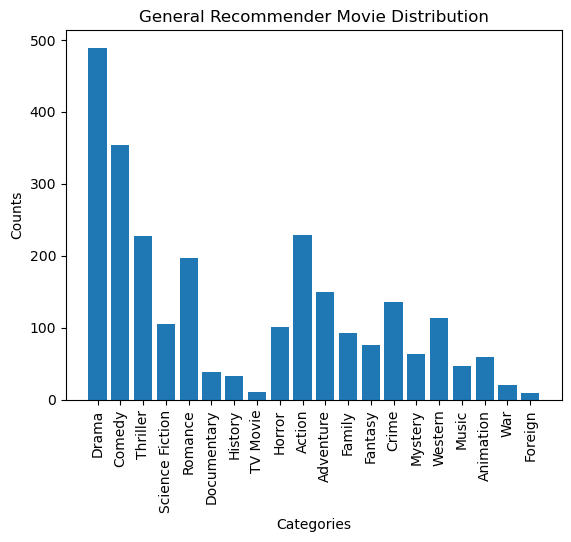

In [29]:
cat_count = {}
for doc in recommenders[f'popular_1_exp_0_seed_{random_seed}'].documents:
    for cat in doc.categories:
        cat_count[cat] = cat_count.get(cat, 0) + 1
cat_count

# Plotting
categories = list(cat_count.keys())
counts = list(cat_count.values())
plt.bar(categories, counts)
plt.xticks(rotation=90)
plt.title('General Recommender Movie Distribution')
plt.xlabel('Categories')
plt.ylabel('Counts')

In [30]:
# ### satisfaction scores for consumers in niche
# niche_consumer_scores = []
# for consumer_id, consumer_object in recommenders[f'popular_1_exp_0_seed_{random_seed}'].connected_consumers.items():
#     if consumer_id in niche_consumers_set:
#         niche_consumer_scores.append(consumer_object.satisfaction_scores)
# niche_consumer_scores

In [31]:
# ### satisfaction scores for the rest of consumers
# general_consumer_scores = []
# for consumer_id, consumer_object in recommenders[f'popular_1_exp_0_seed_{random_seed}'].connected_consumers.items():
#     if consumer_id in general_consumers_set:
#         general_consumer_scores.append(consumer_object.satisfaction_scores)
# general_consumer_scores